# Signal Method Comparison: Fixed Threshold vs Rolling Percentile

**Docker image**: `ml4t`

**Chapter 16: Strategy Simulation**

This notebook provides a systematic comparison of different signal conversion methods
for converting ML prediction scores into actionable trading signals.

**Learning Objectives:**
1. Compare fixed threshold vs rolling percentile signal methods
2. Understand the tradeoffs: signal frequency vs adaptability
3. Analyze turnover implications of different methods
4. See how method choice affects backtest performance

**Key Question:** How do we convert a continuous regression score `y_score`
into a binary trading signal? The ETF and crypto regression scores compared
here are signed and bounded by the model's training distribution rather than
`[0, 1]` — typical ranges run roughly `[-0.022, 0.045]` for the ETF predictor
and a wider signed range for crypto. Classifier-style thresholds such as
`> 0.5` are therefore intentionally degenerate here: they almost never fire
and serve as a foil for adaptive percentile rules. A fixed threshold becomes
useful only after the score scale is calibrated (e.g., by mapping to a
probability or by standardizing within a window).

**Methods Compared:**
1. **Fixed Threshold**: Signal when `y_score > threshold`. Useful when scores
   are calibrated to a fixed scale; degenerate on these uncalibrated
   regression scores.
2. **Rolling Percentile**: Signal when `y_score` exceeds the $N^{\text{th}}$
   percentile of the trailing window. Adapts to drifting score scale.
3. **Cross-Sectional**: Signal for the top $N\%$ of assets at each timestamp.
   Adapts across the universe rather than over time.

## Setup

In [1]:
"""Signal Method Comparison — fixed threshold vs rolling percentile vs cross-sectional signal conversion."""

import warnings
from pathlib import Path

import plotly.graph_objects as go
import polars as pl
from plotly.subplots import make_subplots

warnings.filterwarnings("ignore")

In [2]:
# Production defaults — Papermill injects overrides after this cell
MAX_CONFIGS = 0  # 0 = all configurations

In [3]:
# Signal conversion from shared utilities
from case_studies.utils.model_analysis import load_predictions as load_cs_predictions
from case_studies.utils.signals import (
    cross_sectional_percentile_signal,
    fixed_threshold_signal,
    rolling_percentile_signal,
)
from utils.paths import get_output_dir

DATASET_ALIASES = {
    "crypto": "crypto_perps_funding",
    "etf": "etfs",
}
CANONICAL_DATASET_IDS = set(DATASET_ALIASES.values())

### Dataset Resolution Helpers

Normalize shorthand dataset names to canonical IDs and derive short aliases.

In [4]:
def resolve_dataset_id(dataset: str) -> str:
    if dataset in CANONICAL_DATASET_IDS:
        return dataset
    if dataset in DATASET_ALIASES:
        return DATASET_ALIASES[dataset]
    valid = sorted(CANONICAL_DATASET_IDS | set(DATASET_ALIASES.keys()))
    raise ValueError(f"Unknown dataset: {dataset}. Valid options: {valid}")

### Load Predictions from Case-Study Registry

Predictions live in each case study's `run_log/registry.db`. We load the
GBM configuration with the highest validation IC for a single coherent
score series per (timestamp, symbol).

In [5]:
def load_predictions(dataset: str, family: str = "gbm") -> pl.DataFrame:
    """Load the highest-validation-IC prediction series for a case study from its registry."""
    case_study = resolve_dataset_id(dataset)
    df = load_cs_predictions(case_study, family=family, split="validation")
    if df.is_empty():
        raise FileNotFoundError(f"No {family} validation predictions in {case_study} registry")

    # Select by mean Pearson IC across folds — compute per-fold corr, then
    # average; pooling all rows (the prior implementation) ignores fold
    # structure and gives different rankings than the canonical
    # registry-based selectors.
    config_ic = (
        df.group_by(["config_name", "fold_id"])
        .agg(pl.corr(pl.col("y_score"), pl.col("y_true"), method="pearson").alias("fold_ic"))
        .group_by("config_name")
        .agg(pl.col("fold_ic").mean().alias("ic"))
        .sort("ic", descending=True)
    )
    best_config = config_ic[0, "config_name"]
    return df.filter(pl.col("config_name") == best_config).select(
        ["timestamp", "symbol", "y_score", "y_true", "config_name", "label"]
    )

In [6]:
def list_available_predictions() -> pl.DataFrame:
    """Probe the case-study registries for available GBM validation predictions."""
    rows = []
    for canonical in sorted(CANONICAL_DATASET_IDS):
        try:
            preds = load_cs_predictions(canonical, family="gbm", split="validation")
            n_rows = preds.height
            n_configs = preds["config_name"].n_unique()
            exists = True
        except Exception as e:  # noqa: BLE001
            n_rows = None
            n_configs = None
            exists = False
            preds = None
        rows.append(
            {
                "dataset": canonical,
                "family": "gbm",
                "split": "validation",
                "rows": n_rows,
                "n_configs": n_configs,
                "exists": exists,
            }
        )
    return pl.DataFrame(rows)

## 1. Why Signal Conversion Method Matters

A prediction score is **not** a trading signal. We need to convert it.

| Method | Pros | Cons |
|--------|------|------|
| **Fixed Threshold** | Simple, stable, interpretable | Doesn't adapt to changing distributions |
| **Rolling Percentile** | Adapts to recent prediction distribution | Higher turnover, lookback sensitivity |
| **Cross-Sectional** | Relative ranking, asset-count controlled | Requires multiple assets |

This notebook empirically demonstrates these tradeoffs.

In [7]:
# Configuration
DATASETS = ["crypto", "etf"]  # Primary case studies
ROLLING_WINDOWS = [21, 42, 63]  # 1, 2, 3 months
FIXED_THRESHOLDS = [0.4, 0.5, 0.55, 0.6, 0.65, 0.7]
ROLLING_PERCENTILES = [75, 80, 85, 90, 95]

## 2. Load Predictions Across Datasets

In [8]:
# Check what predictions are available
available = list_available_predictions()

Available prediction sets on disk:

In [9]:
available.filter(pl.col("exists") == True).select(  # noqa: E712
    ["dataset", "family", "split", "rows", "n_configs"]
)

dataset,family,split,rows,n_configs
str,str,str,i64,i64
"""crypto_perps_funding""","""gbm""","""validation""",1593027,25
"""etfs""","""gbm""","""validation""",7609360,15


In [10]:
# Load the highest-validation-IC GBM predictions for each dataset from its case-study registry.
predictions = {}

for dataset_alias in DATASETS:
    dataset_id = resolve_dataset_id(dataset_alias)
    preds = load_predictions(dataset_alias, family="gbm")
    config_name = preds["config_name"][0] if preds.height else "n/a"
    label = preds["label"][0] if preds.height else "n/a"
    predictions[dataset_id] = {
        "family": "gbm",
        "config": config_name,
        "label": label,
        "data": preds,
    }
    print(
        f"[OK] {dataset_id}: gbm config={config_name} (highest validation IC), "
        f"label={label} ({len(preds):,} rows)"
    )

if not predictions:
    raise FileNotFoundError(
        "No GBM predictions in case-study registries. Run upstream training first."
    )

print(f"\nTotal: {len(predictions)} prediction sets loaded")

[OK] crypto_perps_funding: gbm config=leaves_7_huber (highest validation IC), label=fwd_ret_8h (350,281 rows)


[OK] etfs: gbm config=leaves_7_mae (highest validation IC), label=fwd_ret_21d (380,468 rows)

Total: 2 prediction sets loaded


## 3. Signal Method Comparison Function

In [11]:
def comprehensive_signal_comparison(
    preds: pl.DataFrame,
    dataset_name: str,
    fixed_thresholds: list[float] = None,
    rolling_windows: list[int] = None,
    rolling_percentiles: list[float] = None,
) -> pl.DataFrame:
    """Run comprehensive signal method comparison.

    Args:
        preds: Predictions DataFrame
        dataset_name: Name for identification
        fixed_thresholds: List of fixed threshold values
        rolling_windows: List of rolling window sizes
        rolling_percentiles: List of percentile values

    Returns:
        Comparison DataFrame with all method combinations
    """
    if fixed_thresholds is None:
        fixed_thresholds = FIXED_THRESHOLDS
    if rolling_windows is None:
        rolling_windows = ROLLING_WINDOWS
    if rolling_percentiles is None:
        rolling_percentiles = ROLLING_PERCENTILES

    results = []

    # Check prediction distribution
    y_min = preds["y_score"].min()
    y_max = preds["y_score"].max()
    y_mean = preds["y_score"].mean()
    y_std = preds["y_score"].std()

    # Fixed threshold signals
    for threshold in fixed_thresholds:
        signals = fixed_threshold_signal(preds, threshold=threshold)
        n_signals = signals.filter(pl.col("signal") != 0).height
        signal_rate = n_signals / len(preds) if len(preds) > 0 else 0

        # Turnover: count signal changes
        sorted_signals = signals.sort(["symbol", "timestamp"])
        turnover_df = sorted_signals.with_columns(
            (pl.col("signal") != pl.col("signal").shift(1).over("symbol"))
            .fill_null(False)
            .alias("changed")
        )
        turnover = turnover_df["changed"].sum() / len(preds) if len(preds) > 0 else 0

        results.append(
            {
                "dataset": dataset_name,
                "method": "fixed_threshold",
                "threshold": threshold,
                "window": None,
                "percentile": None,
                "n_signals": n_signals,
                "signal_rate": signal_rate,
                "turnover_rate": turnover,
                "n_dates": signals["timestamp"].n_unique() if "timestamp" in signals.columns else 0,
            }
        )

    # Rolling percentile signals
    for window in rolling_windows:
        for percentile in rolling_percentiles:
            try:
                signals = rolling_percentile_signal(
                    preds, window=window, percentile=float(percentile)
                )
                n_signals = signals.filter(pl.col("signal") != 0).height
                signal_rate = n_signals / len(preds) if len(preds) > 0 else 0

                # Turnover
                sorted_signals = signals.sort(["symbol", "timestamp"])
                turnover_df = sorted_signals.with_columns(
                    (pl.col("signal") != pl.col("signal").shift(1).over("symbol"))
                    .fill_null(False)
                    .alias("changed")
                )
                turnover = turnover_df["changed"].sum() / len(preds) if len(preds) > 0 else 0

                results.append(
                    {
                        "dataset": dataset_name,
                        "method": "rolling_percentile",
                        "threshold": None,
                        "window": window,
                        "percentile": percentile,
                        "n_signals": n_signals,
                        "signal_rate": signal_rate,
                        "turnover_rate": turnover,
                        "n_dates": signals["timestamp"].n_unique()
                        if "timestamp" in signals.columns
                        else 0,
                    }
                )
            except (pl.exceptions.ComputeError, ValueError) as e:
                print(f"  Warning: rolling_percentile(w={window}, p={percentile}) failed: {e}")

    # Cross-sectional signals
    for percentile in rolling_percentiles:
        try:
            signals = cross_sectional_percentile_signal(preds, percentile=float(percentile))
            n_signals = signals.filter(pl.col("signal") != 0).height
            signal_rate = n_signals / len(preds) if len(preds) > 0 else 0

            # Turnover
            sorted_signals = signals.sort(["symbol", "timestamp"])
            turnover_df = sorted_signals.with_columns(
                (pl.col("signal") != pl.col("signal").shift(1).over("symbol"))
                .fill_null(False)
                .alias("changed")
            )
            turnover = turnover_df["changed"].sum() / len(preds) if len(preds) > 0 else 0

            results.append(
                {
                    "dataset": dataset_name,
                    "method": "cross_sectional",
                    "threshold": None,
                    "window": None,
                    "percentile": percentile,
                    "n_signals": n_signals,
                    "signal_rate": signal_rate,
                    "turnover_rate": turnover,
                    "n_dates": signals["timestamp"].n_unique()
                    if "timestamp" in signals.columns
                    else 0,
                }
            )
        except (pl.exceptions.ComputeError, ValueError) as e:
            print(f"  Warning: cross_sectional(p={percentile}) failed: {e}")

    return pl.DataFrame(results)

## 4. Run Comparison Across All Datasets

In [12]:
all_results = []

for dataset_name, pred_info in predictions.items():
    preds = pred_info["data"]
    print(f"\n=== {dataset_name} ({pred_info['family']} {pred_info['config']}) ===")

    # Show prediction distribution
    y_min = preds["y_score"].min()
    y_max = preds["y_score"].max()
    y_mean = preds["y_score"].mean()
    print(f"  y_score range: [{y_min:.3f}, {y_max:.3f}], mean={y_mean:.3f}")
    print(f"  Total predictions: {len(preds):,}")

    # Run comparison
    results = comprehensive_signal_comparison(preds, dataset_name)
    all_results.append(results)

# Combine all results
comparison_df = pl.concat(all_results)

print(f"\n[OK] Total method comparisons: {len(comparison_df)}")


=== crypto_perps_funding (gbm leaves_7_huber) ===
  y_score range: [-0.081, 0.189], mean=-0.008
  Total predictions: 350,281



=== etfs (gbm leaves_7_mae) ===
  y_score range: [-0.022, 0.045], mean=0.004
  Total predictions: 380,468



[OK] Total method comparisons: 52


## 5. Fixed Threshold Analysis

In [13]:
# Analyze fixed threshold results
fixed_results = (
    comparison_df.filter(pl.col("method") == "fixed_threshold")
    .select(["dataset", "threshold", "signal_rate", "turnover_rate", "n_signals"])
    .sort(["dataset", "threshold"])
)

**Fixed-threshold signal rates** by dataset and threshold value:

In [14]:
fixed_results

dataset,threshold,signal_rate,turnover_rate,n_signals
str,f64,f64,f64,i64
"""crypto_perps_funding""",0.4,0.0,0.0,0
"""crypto_perps_funding""",0.5,0.0,0.0,0
"""crypto_perps_funding""",0.55,0.0,0.0,0
"""crypto_perps_funding""",0.6,0.0,0.0,0
"""crypto_perps_funding""",0.65,0.0,0.0,0
…,…,…,…,…
"""etfs""",0.5,0.0,0.0,0
"""etfs""",0.55,0.0,0.0,0
"""etfs""",0.6,0.0,0.0,0


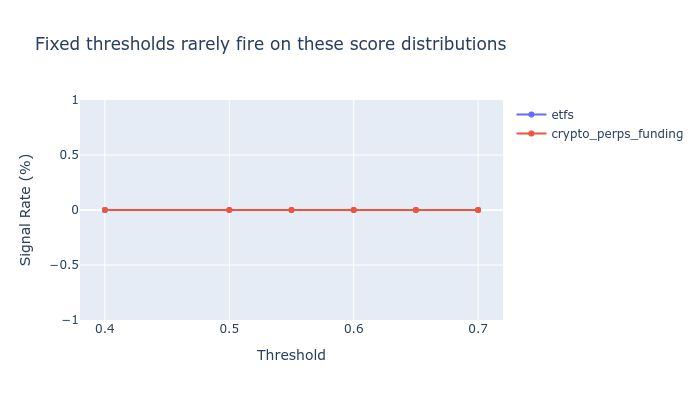

In [15]:
# Visualize fixed threshold signal rates
fig = go.Figure()

for dataset in comparison_df["dataset"].unique().to_list():
    data = fixed_results.filter(pl.col("dataset") == dataset)
    if len(data) > 0:
        fig.add_trace(
            go.Scatter(
                x=data["threshold"].to_list(),
                y=[r * 100 for r in data["signal_rate"].to_list()],
                name=dataset,
                mode="lines+markers",
            )
        )

fig.update_layout(
    title="Fixed thresholds rarely fire on these score distributions",
    xaxis_title="Threshold",
    yaxis_title="Signal Rate (%)",
    height=400,
)
fig.show()

## 6. Rolling Percentile Analysis

In [16]:
# Analyze rolling percentile results
rolling_results = (
    comparison_df.filter(pl.col("method") == "rolling_percentile")
    .select(["dataset", "window", "percentile", "signal_rate", "turnover_rate"])
    .sort(["dataset", "window", "percentile"])
)

**Rolling-percentile signal rates** by dataset, window, and percentile:

In [17]:
rolling_results

dataset,window,percentile,signal_rate,turnover_rate
str,i64,i64,f64,f64
"""crypto_perps_funding""",21,75,0.25403,0.309848
"""crypto_perps_funding""",21,80,0.213357,0.277474
"""crypto_perps_funding""",21,85,0.168045,0.231751
"""crypto_perps_funding""",21,90,0.123327,0.186256
"""crypto_perps_funding""",21,95,0.066621,0.107759
…,…,…,…,…
"""etfs""",63,75,0.224686,0.30658
"""etfs""",63,80,0.184481,0.260908
"""etfs""",63,85,0.144987,0.21277


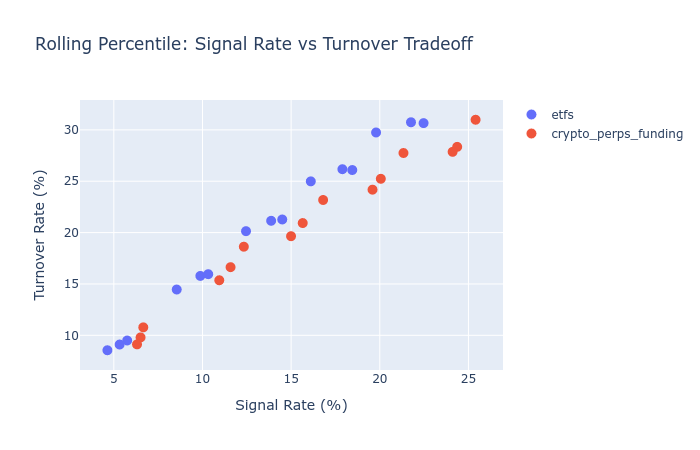

In [18]:
# Visualize turnover vs signal rate tradeoff
fig = go.Figure()

for dataset in comparison_df["dataset"].unique().to_list():
    data = comparison_df.filter(
        (pl.col("dataset") == dataset) & (pl.col("method") == "rolling_percentile")
    )
    if len(data) > 0:
        fig.add_trace(
            go.Scatter(
                x=[r * 100 for r in data["signal_rate"].to_list()],
                y=[r * 100 for r in data["turnover_rate"].to_list()],
                name=dataset,
                mode="markers",
                marker=dict(size=10),
                text=[
                    f"w={w}, p={p}"
                    for w, p in zip(
                        data["window"].to_list(), data["percentile"].to_list(), strict=False
                    )
                ],
                hovertemplate="%{text}<br>Signal: %{x:.1f}%<br>Turnover: %{y:.1f}%",
            )
        )

fig.update_layout(
    title="Rolling Percentile: Signal Rate vs Turnover Tradeoff",
    xaxis_title="Signal Rate (%)",
    yaxis_title="Turnover Rate (%)",
    height=450,
)
fig.show()

## 7. Method Comparison: Fixed vs Rolling vs Cross-Sectional

In [19]:
# Compare methods at similar signal rates
# Find roughly 20% signal rate for each method type


def find_closest_signal_rate(df, method, target_rate=0.20):
    """Find method configuration closest to target signal rate."""
    method_df = df.filter(pl.col("method") == method)
    if len(method_df) == 0:
        return None

    # Add distance column
    with_dist = method_df.with_columns((pl.col("signal_rate") - target_rate).abs().alias("dist"))
    closest = with_dist.sort("dist").head(1)
    return closest


print("=== Method Comparison at ~20% Signal Rate ===")
for dataset in comparison_df["dataset"].unique().to_list():
    print(f"\n{dataset}:")
    data = comparison_df.filter(pl.col("dataset") == dataset)

    for method in ["fixed_threshold", "rolling_percentile", "cross_sectional"]:
        closest = find_closest_signal_rate(data, method, target_rate=0.20)
        if closest is not None and len(closest) > 0:
            row = closest.to_dicts()[0]
            config = ""
            if method == "fixed_threshold":
                config = f"threshold={row['threshold']}"
            elif method == "rolling_percentile":
                config = f"window={row['window']}, percentile={row['percentile']}"
            else:
                config = f"percentile={row['percentile']}"

            print(f"  {method}: {config}")
            print(
                f"    Signal rate: {row['signal_rate'] * 100:.1f}%, Turnover: {row['turnover_rate'] * 100:.1f}%"
            )

=== Method Comparison at ~20% Signal Rate ===

crypto_perps_funding:
  fixed_threshold: threshold=0.4
    Signal rate: 0.0%, Turnover: 0.0%
  rolling_percentile: window=42, percentile=80
    Signal rate: 20.1%, Turnover: 25.2%
  cross_sectional: percentile=80
    Signal rate: 20.6%, Turnover: 28.0%

etfs:
  fixed_threshold: threshold=0.4
    Signal rate: 0.0%, Turnover: 0.0%
  rolling_percentile: window=21, percentile=75
    Signal rate: 19.8%, Turnover: 29.7%
  cross_sectional: percentile=85
    Signal rate: 17.8%, Turnover: 29.2%


## 8. Window Size Sensitivity

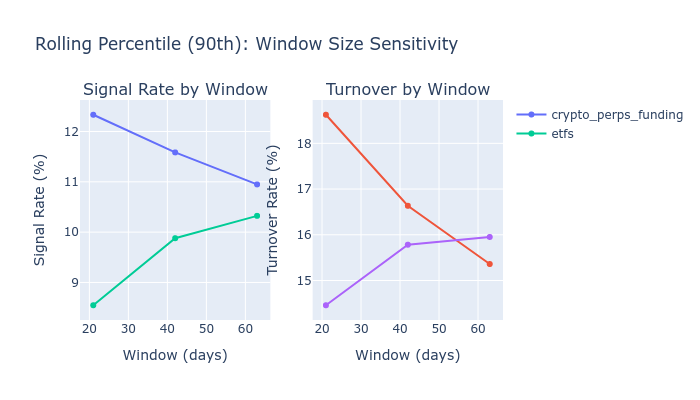

In [20]:
# Analyze how window size affects rolling percentile signals
fig = make_subplots(rows=1, cols=2, subplot_titles=["Signal Rate by Window", "Turnover by Window"])

for dataset in predictions.keys():
    data = comparison_df.filter(
        (pl.col("dataset") == dataset)
        & (pl.col("method") == "rolling_percentile")
        & (pl.col("percentile") == 90)  # Fix percentile
    ).sort("window")

    if len(data) > 0:
        fig.add_trace(
            go.Scatter(
                x=data["window"].to_list(),
                y=[r * 100 for r in data["signal_rate"].to_list()],
                name=dataset,
                mode="lines+markers",
            ),
            row=1,
            col=1,
        )
        fig.add_trace(
            go.Scatter(
                x=data["window"].to_list(),
                y=[r * 100 for r in data["turnover_rate"].to_list()],
                name=dataset,
                mode="lines+markers",
                showlegend=False,
            ),
            row=1,
            col=2,
        )

fig.update_layout(
    title="Rolling Percentile (90th): Window Size Sensitivity",
    height=400,
)
fig.update_xaxes(title_text="Window (days)", row=1, col=1)
fig.update_xaxes(title_text="Window (days)", row=1, col=2)
fig.update_yaxes(title_text="Signal Rate (%)", row=1, col=1)
fig.update_yaxes(title_text="Turnover Rate (%)", row=1, col=2)
fig.show()

## 9. Percentile Sensitivity

In [21]:
# Analyze how percentile threshold affects signals
fig = make_subplots(
    rows=1, cols=2, subplot_titles=["Signal Rate by Percentile", "Turnover by Percentile"]
)

for dataset in predictions.keys():
    data = comparison_df.filter(
        (pl.col("dataset") == dataset)
        & (pl.col("method") == "rolling_percentile")
        & (pl.col("window") == 21)  # Fix window to 21 days
    ).sort("percentile")

    if len(data) > 0:
        fig.add_trace(
            go.Scatter(
                x=data["percentile"].to_list(),
                y=[r * 100 for r in data["signal_rate"].to_list()],
                name=dataset,
                mode="lines+markers",
            ),
            row=1,
            col=1,
        )
        fig.add_trace(
            go.Scatter(
                x=data["percentile"].to_list(),
                y=[r * 100 for r in data["turnover_rate"].to_list()],
                name=dataset,
                mode="lines+markers",
                showlegend=False,
            ),
            row=1,
            col=2,
        )

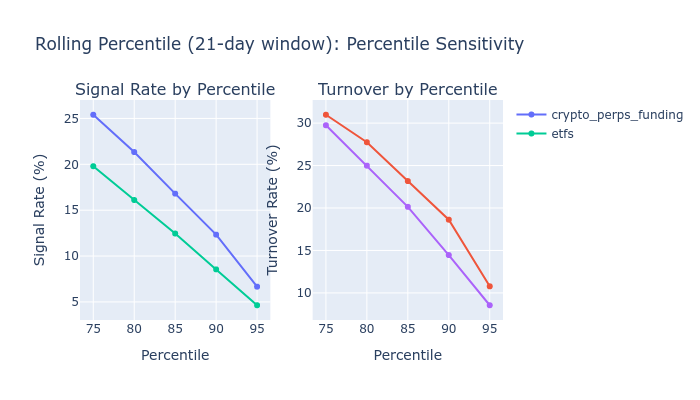

In [22]:
# Layout and display
fig.update_layout(
    title="Rolling Percentile (21-day window): Percentile Sensitivity",
    height=400,
)
fig.update_xaxes(title_text="Percentile", row=1, col=1)
fig.update_xaxes(title_text="Percentile", row=1, col=2)
fig.update_yaxes(title_text="Signal Rate (%)", row=1, col=1)
fig.update_yaxes(title_text="Turnover Rate (%)", row=1, col=2)
fig.show()

## 10. Key Findings and Recommendations

In [23]:
print("\n" + "=" * 80)
print("SIGNAL METHOD COMPARISON: KEY FINDINGS")
print("=" * 80)

print("\n--- Fixed Threshold ---")
print("  Pros:")
print("    + Simple to implement and interpret")
print("    + Stable, predictable signal frequency")
print("    + Lower turnover than adaptive methods")
print("  Cons:")
print("    - Doesn't adapt to changing prediction distributions")
print("    - May miss signals in low-conviction periods")
print("    - Requires recalibration if model changes")
print("  Best for: Production systems with stable models")

print("\n--- Rolling Percentile ---")
print("  Pros:")
print("    + Adapts to recent prediction distribution")
print("    + Consistent relative signal frequency")
print("    + Handles regime changes gracefully")
print("  Cons:")
print("    - Higher turnover than fixed threshold")
print("    - Window size sensitivity")
print("    - Lookback period introduces lag")
print("  Best for: Dynamic markets, regime-switching strategies")

print("\n--- Cross-Sectional ---")
print("  Pros:")
print("    + Relative ranking across assets")
print("    + Controlled position count (top N)")
print("    + Naturally handles varying score distributions")
print("  Cons:")
print("    - Requires multiple assets")
print("    - Always generates signals (even in bad times)")
print("    - May force positions in weak assets")
print("  Best for: Multi-asset portfolios, sector rotation")

print("\n--- Recommendations ---")
print("  1. Fixed thresholds require model-specific score-scale calibration —")
print("     do not apply a 0.5 binary threshold to a signed regression score")
print("  2. The 63-day 90th rolling percentile is the recommended baseline for")
print("     these case-study predictions (lowest turnover at ~10% signal rate)")
print("  3. Cross-sectional ranking for multi-asset portfolio allocation")
print("  4. Always monitor turnover implications")
print("  5. Transaction costs favor lower turnover methods")


SIGNAL METHOD COMPARISON: KEY FINDINGS

--- Fixed Threshold ---
  Pros:
    + Simple to implement and interpret
    + Stable, predictable signal frequency
    + Lower turnover than adaptive methods
  Cons:
    - Doesn't adapt to changing prediction distributions
    - May miss signals in low-conviction periods
    - Requires recalibration if model changes
  Best for: Production systems with stable models

--- Rolling Percentile ---
  Pros:
    + Adapts to recent prediction distribution
    + Consistent relative signal frequency
    + Handles regime changes gracefully
  Cons:
    - Higher turnover than fixed threshold
    - Window size sensitivity
    - Lookback period introduces lag
  Best for: Dynamic markets, regime-switching strategies

--- Cross-Sectional ---
  Pros:
    + Relative ranking across assets
    + Controlled position count (top N)
    + Naturally handles varying score distributions
  Cons:
    - Requires multiple assets
    - Always generates signals (even in bad times

## 11. Summary Table

In [24]:
# Create summary by method type
method_summary = (
    comparison_df.group_by("method")
    .agg(
        [
            pl.col("signal_rate").mean().alias("avg_signal_rate"),
            pl.col("signal_rate").std().alias("std_signal_rate"),
            pl.col("turnover_rate").mean().alias("avg_turnover"),
            pl.col("turnover_rate").std().alias("std_turnover"),
            pl.len().alias("n_configs"),
        ]
    )
    .sort("method")
)

**Method summary** averaged across all configurations:

In [25]:
method_summary

method,avg_signal_rate,std_signal_rate,avg_turnover,std_turnover,n_configs
str,f64,f64,f64,f64,u32
"""cross_sectional""",0.16648,0.076143,0.252196,0.110168,10
"""fixed_threshold""",0.0,0.0,0.0,0.0,12
"""rolling_percentile""",0.146141,0.062897,0.204238,0.073276,30


In [26]:
# Dataset-specific recommendations
print("\n=== Dataset-Specific Recommendations ===")
for dataset in predictions.keys():
    data = comparison_df.filter(pl.col("dataset") == dataset)

    # Find lowest turnover with reasonable signal rate
    reasonable = data.filter(pl.col("signal_rate") >= 0.10)
    if len(reasonable) > 0:
        best = reasonable.sort("turnover_rate").head(1).to_dicts()[0]
        print(f"\n{dataset}:")
        print(f"  Recommended: {best['method']}")
        if best["method"] == "fixed_threshold":
            print(f"  Config: threshold={best['threshold']}")
        elif best["method"] == "rolling_percentile":
            print(f"  Config: window={best['window']}, percentile={best['percentile']}")
        else:
            print(f"  Config: percentile={best['percentile']}")
        print(f"  Signal rate: {best['signal_rate'] * 100:.1f}%")
        print(f"  Turnover rate: {best['turnover_rate'] * 100:.1f}%")


=== Dataset-Specific Recommendations ===

crypto_perps_funding:
  Recommended: rolling_percentile
  Config: window=63, percentile=90
  Signal rate: 10.9%
  Turnover rate: 15.4%

etfs:
  Recommended: rolling_percentile
  Config: window=63, percentile=90
  Signal rate: 10.3%
  Turnover rate: 16.0%


## 12. Save Results

In [27]:
# Save comparison results for reference
OUTPUT_DIR = get_output_dir(16, "signal_method_comparison")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

comparison_df.write_parquet(OUTPUT_DIR / "method_comparison.parquet")
print(f"\nSaved: {OUTPUT_DIR / 'method_comparison.parquet'}")

method_summary.write_parquet(OUTPUT_DIR / "method_summary.parquet")
print(f"Saved: {OUTPUT_DIR / 'method_summary.parquet'}")

print("\n[OK] Signal method comparison complete")


Saved: 16_strategy_simulation/output/signal_method_comparison/method_comparison.parquet
Saved: 16_strategy_simulation/output/signal_method_comparison/method_summary.parquet

[OK] Signal method comparison complete


## Key Takeaways

1. **Signal method matters as much as the signal itself**: The same underlying
   prediction can produce meaningfully different backtest outcomes depending
   on how it is converted to positions (fixed threshold, percentile, cross-sectional).

2. **Cross-sectional methods adapt to changing signal distributions**: by
   selecting top/bottom quantiles, they produce a positive signal rate by
   construction, regardless of where the prediction distribution sits. The
   per-configuration signal-rate table earlier in the notebook reports the
   measured values; fixed-threshold methods can collapse to zero for any
   (dataset, threshold) pair where predictions never cross the cutoff. The
   notebook does not separately evaluate regime-conditional consistency —
   only configuration-level signal-rate dispersion.

3. **Threshold sensitivity reveals fragility**: A strategy that works only
   for a narrow threshold range is likely overfit to the backtest period.

4. **Signal rate and turnover are connected**: Higher signal rates typically
   increase turnover, which increases transaction costs. The optimal method
   balances signal quality against execution cost.

**Next**: Chapter 20's signal quality and signal-to-strategy notebooks show
how these entry-scheme choices play out across all nine case studies.

**Book**: Section 16.2 discusses the trading protocol specification that
determines how signals become positions.